# COMP VISION PROJECT

## Task 1-2

In [ ]:
# # 1) Build coco_filtered/ (YOLO labels + optional image download)
# !python scripts/prepare_coco_subset.py --verify

# # 2) Build curated_yolo/ with reproducible 80/10/10 split
# !python scripts/split_yolo_dataset.py --force

## Common libraries + helper functions

In [1]:
%matplotlib inline
import cv2
import math
from pathlib import Path
from matplotlib import pyplot as plt
from ultralytics import YOLO

def display_image_subplots(image_filenames, image_dir, num_images, num_cols):
    if num_cols <= 0:
        raise ValueError("num_cols must be greater than 0")
    if num_images <= 0:
        raise ValueError("num_images must be greater than 0")
    if not image_filenames:
        raise ValueError("image_filenames cannot be empty")

    image_dir = Path(image_dir)
    selected_files = image_filenames[: min(num_images, len(image_filenames))]
    num_rows = math.ceil(len(selected_files) / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15 * num_cols, 10 * num_rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, filename in enumerate(selected_files):
        img_path = image_dir / filename
        img = cv2.imread(str(img_path))

        if img is None:
            axes[i].text(0.5, 0.5, f"Missing:\n{filename}", ha="center", va="center")
            axes[i].set_title(filename)
            axes[i].axis("off")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(filename)
        axes[i].axis("off")

    # Hide any unused subplot slots
    for j in range(len(selected_files), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# CONSTANT
GRAPH_FILENAMES = [
    "results.png",
    "confusion_matrix.png",
    "BoxF1_curve.png",
    "BoxR_curve.png",
    "BoxP_curve.png"
]

DATASET_DIR = "curated_yolo"

## Task 3

### Train: default settings

In [2]:

# 1) load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# 2) train using your dataset yaml
model.train(
    data="curated_yolo/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0  # use "cpu" if no GPU
)

New https://pypi.org/project/ultralytics/8.4.39 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.32  Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=curated_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tr

c:\Users\Sonia Lim\anaconda3\envs\polyu_y3t2\Lib\site-packages\ultralytics\utils\plotting.py:872: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy.ndimage import gaussian_filter1d


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001A3424E6DB0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

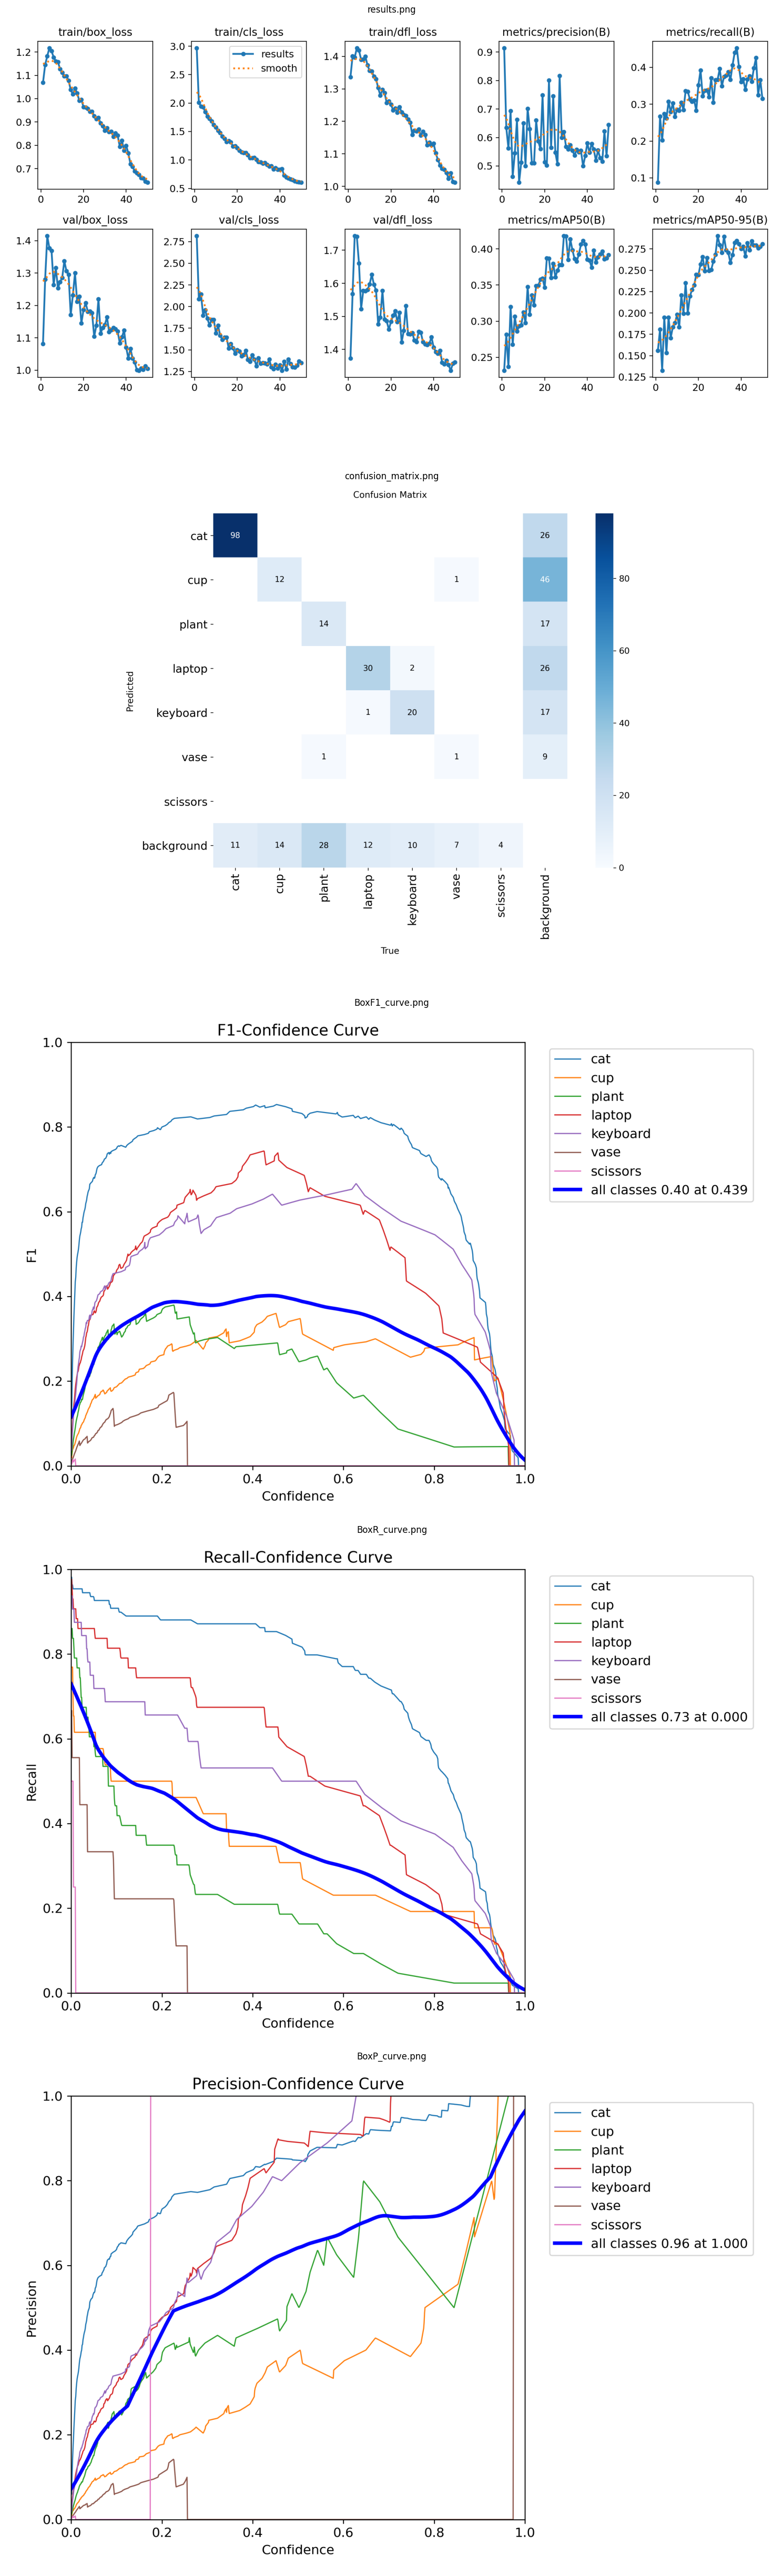

In [3]:
# 3) display training graphs
display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir="runs/detect/train",
    num_images=5,
    num_cols=1,
)

### Train 2: 
* increase epochs from 50 - 100
* image size increase
* patience

In [4]:
from ultralytics import YOLO

# 1) load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# 2) train using your dataset yaml (with workers=0 to fix Windows multiprocessing issue)
model.train(
    data="curated_yolo/data.yaml",
    epochs=100,
    imgsz=800,
    batch=16,
    device=0,  # use "cpu" if no GPU
    workers=0,  # Fix for Windows: disable multiprocessing
    patience=20  # Early stopping if no improvement
)

New https://pypi.org/project/ultralytics/8.4.39 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.32  Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=curated_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=t

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001A43E4E9D60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

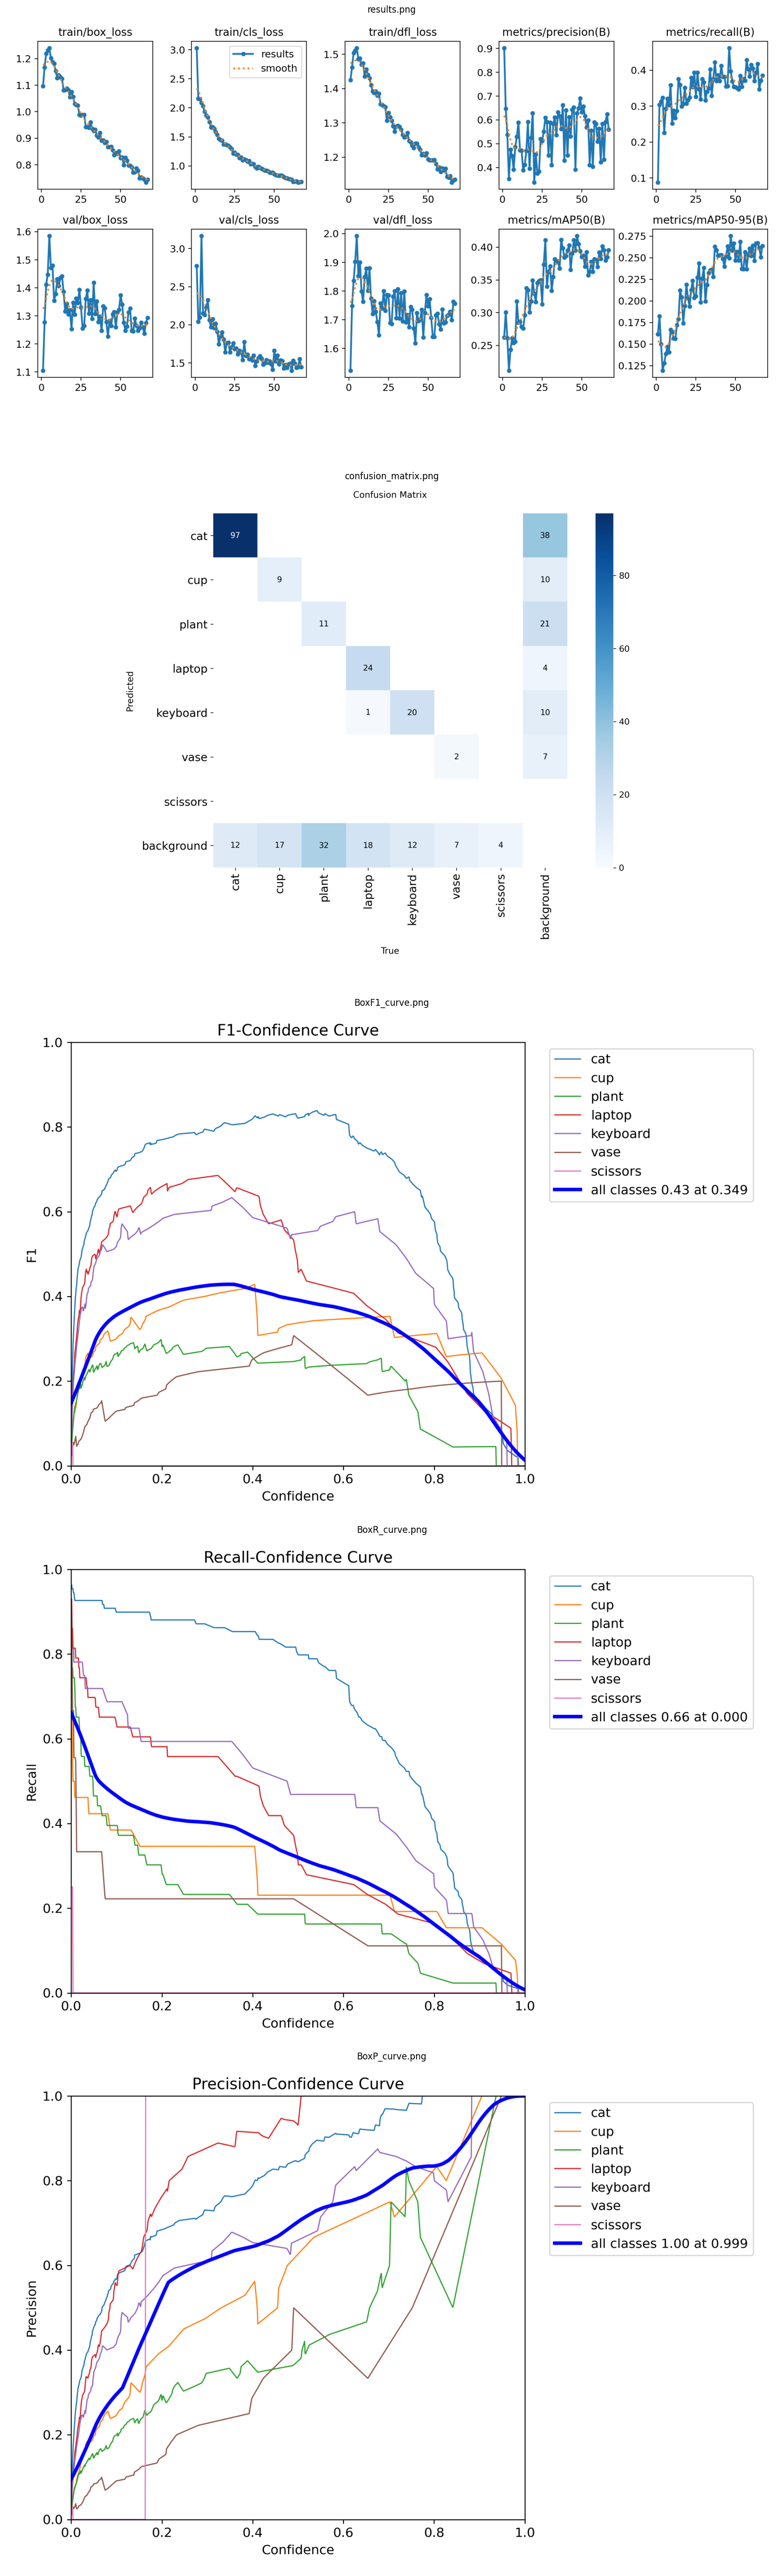

In [5]:

display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir="runs/detect/train2",
    num_images=5,
    num_cols=1,
)


## Train 3: 
* add data augmentations

In [6]:
from ultralytics import YOLO

# 1) load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# 2) train using your dataset yaml (with workers=0 to fix Windows multiprocessing issue)
model.train(
    data="curated_yolo/data.yaml",
    epochs=100,
    imgsz=800,
    batch=16,
    device=0, 
    workers=0,  
    patience=20, 

    # Data augmentation parameters
    mosaic=1.0,
    mixup=0.2,
    scale=0.5
)

New https://pypi.org/project/ultralytics/8.4.39 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.32  Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=curated_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=t

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001A43C1481A0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

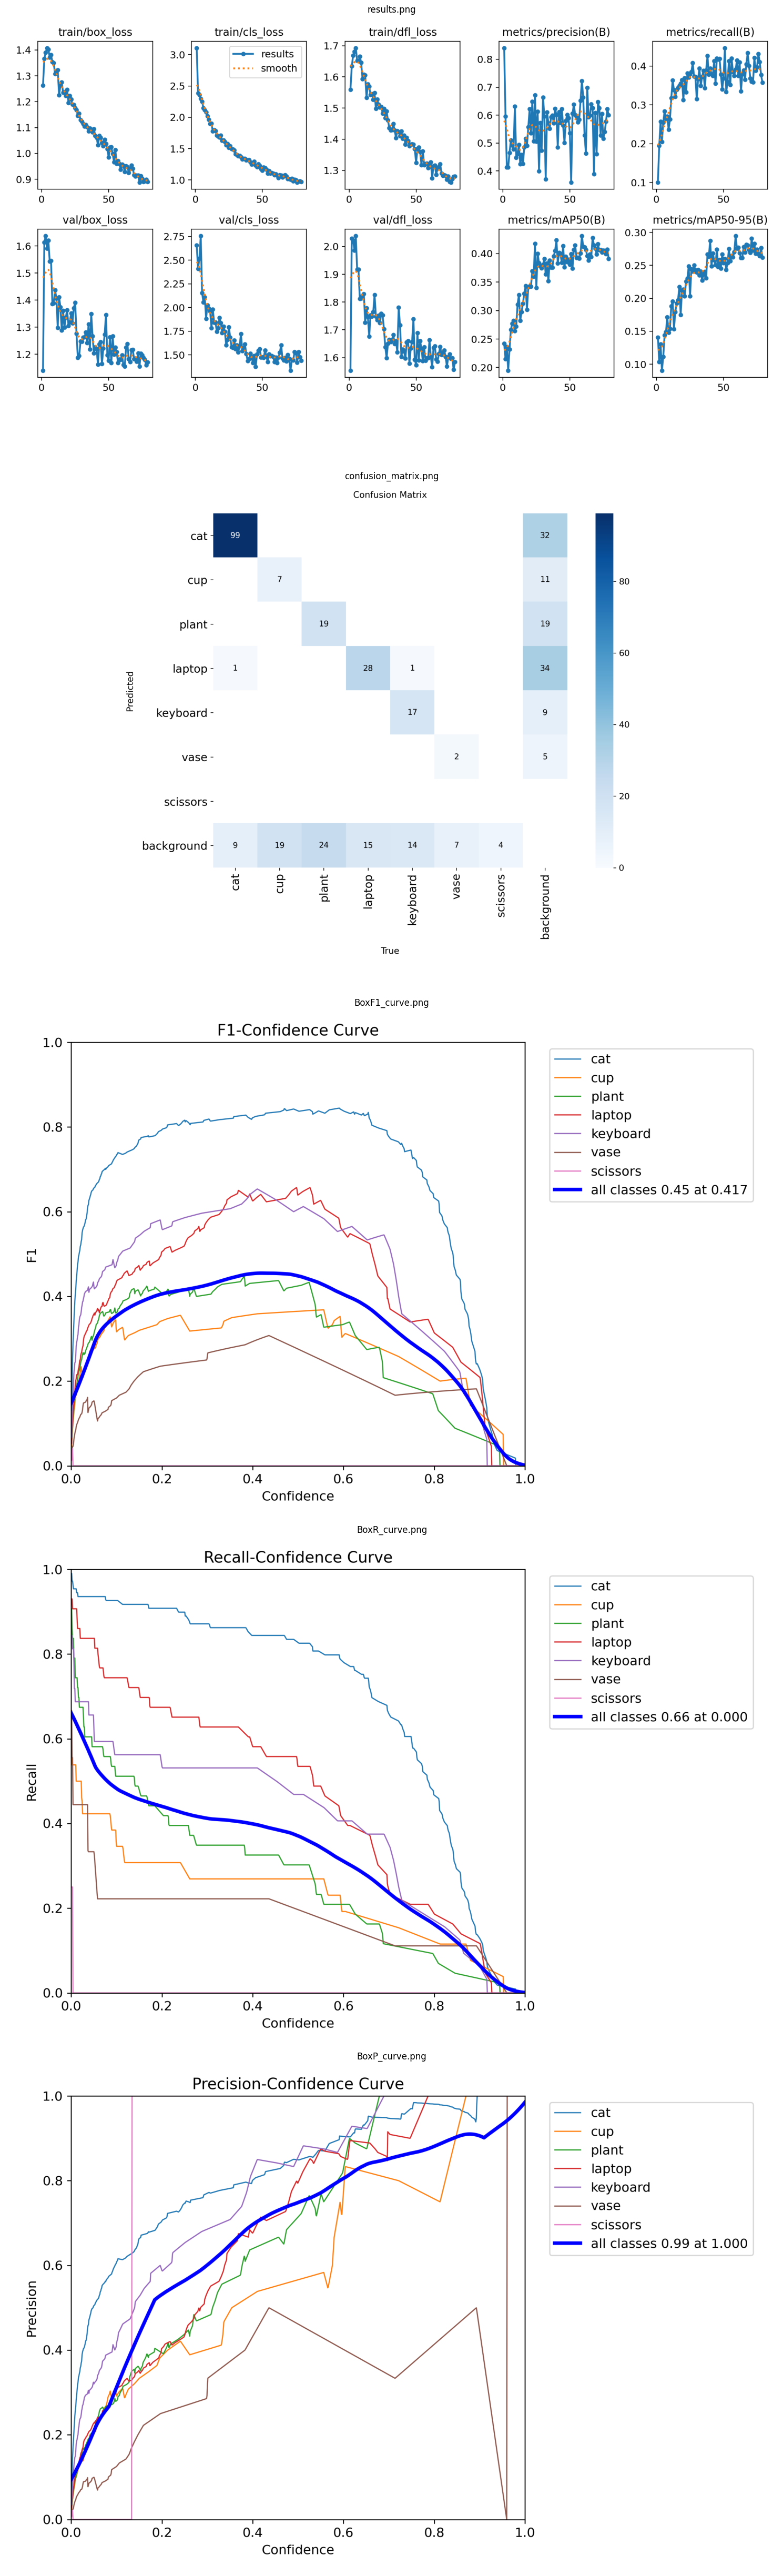

In [7]:
display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir="runs/detect/train3",
    num_images=5,
    num_cols=1,
)


## Train 4: 
* freeze first 5 layers

In [13]:
from ultralytics import YOLO

# 1) load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# 2) train using your dataset yaml (with workers=0 to fix Windows multiprocessing issue)
model.train(
    data="curated_yolo/data.yaml",
    epochs=100,
    imgsz=800,
    batch=16,
    device=0, 
    workers=0,  
    patience=20, 
    freeze=5,  # Freeze first 5 layers

    # Data augmentation parameters
    mosaic=1.0,
    mixup=0.2,
    scale=0.5
)

New https://pypi.org/project/ultralytics/8.4.39 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.32  Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=curated_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=5, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=trai

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001A43E5471A0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

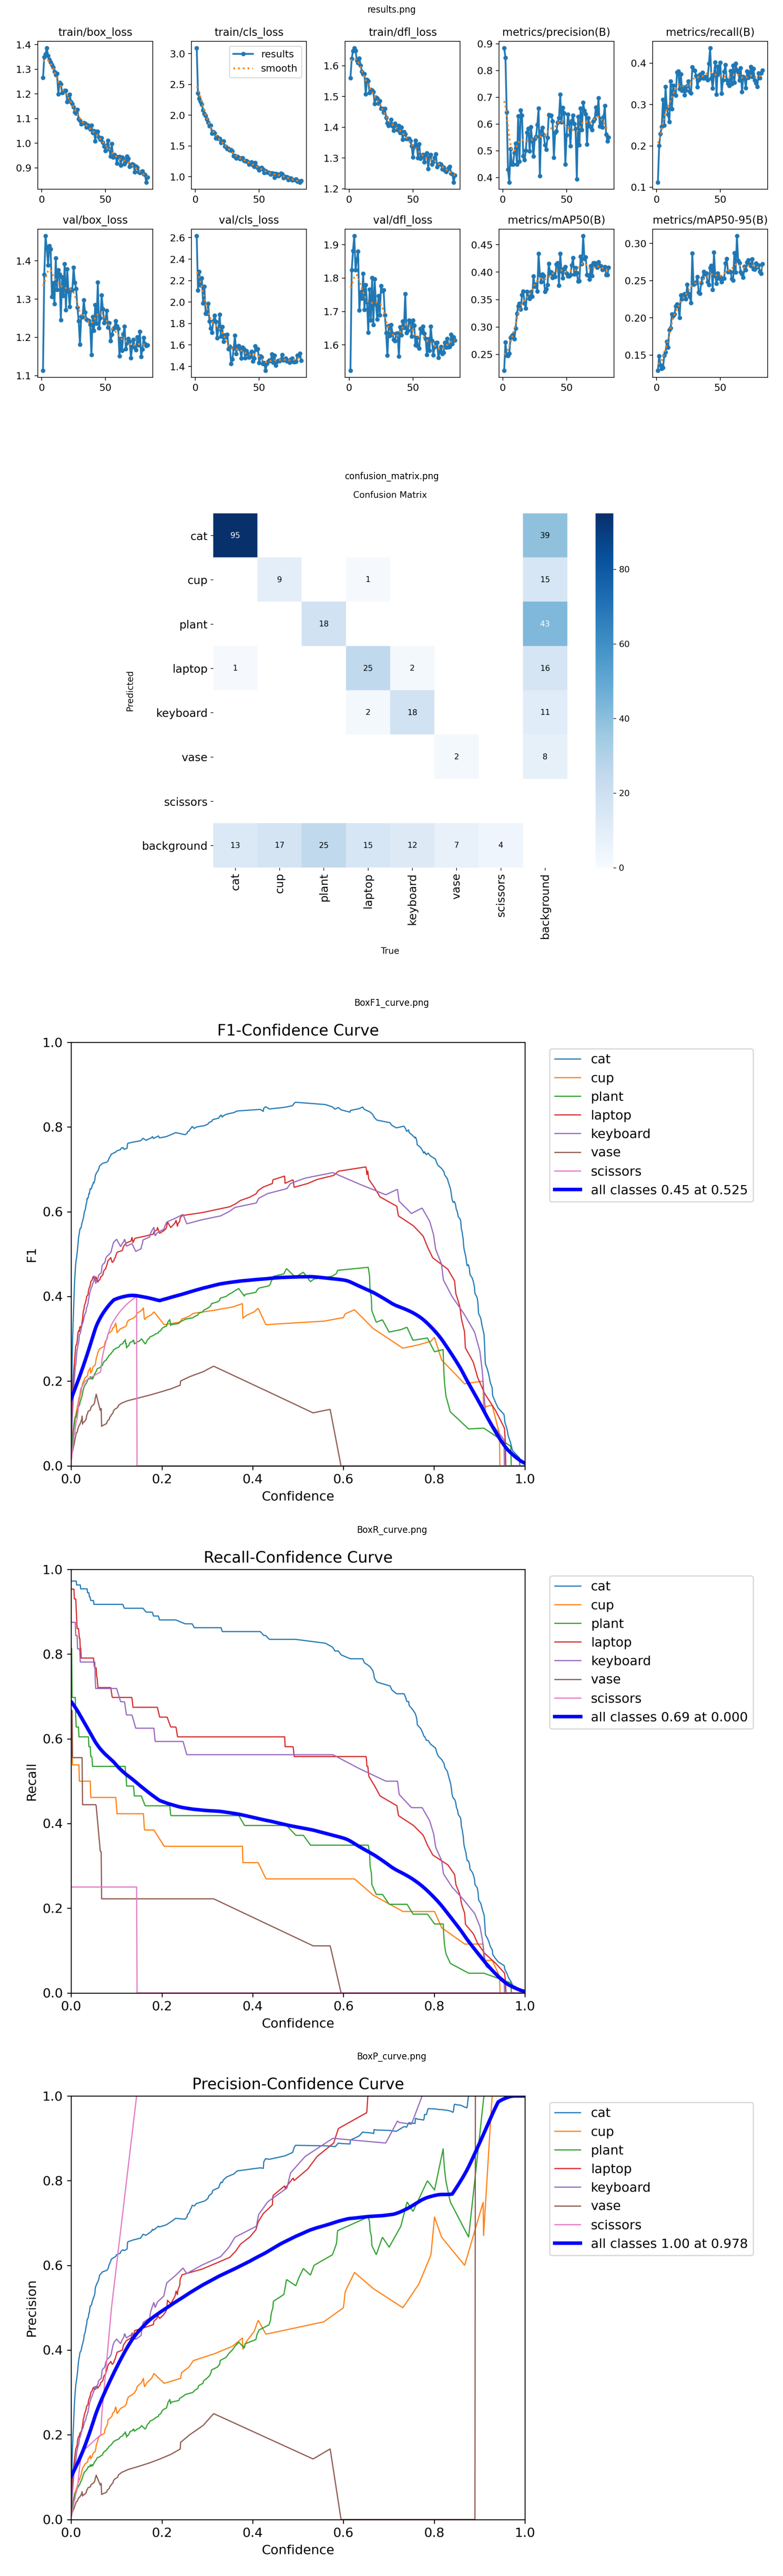

In [18]:
display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir="runs/detect/train4",
    num_images=5,
    num_cols=1,
)